# 📊 Mục 2 — Exploratory Data Analysis (EDA)
## German Credit Risk Scoring Application

> **Mục tiêu:** Phân tích phân phối dữ liệu, default rate theo các biến chính, kiểm tra class imbalance và tìm key insights từ German Credit Dataset.

---

## ⚙️ Bước 1 — Cấu hình & Tự động tìm đường dẫn Data

In [1]:
import os

# ══════════════════════════════════════════════════════════════
# TỰ ĐỘNG TÌM THƯ MỤC DATA (không dùng __file__ vì chạy Jupyter)
# Cấu trúc thư mục kỳ vọng:
#   DAP_PRroject_Final/
#   ├── Data/
#   │   ├── german.data
#   │   └── german.data-numeric
#   └── Notebooks/   <-- notebook đang chạy ở đây
# ══════════════════════════════════════════════════════════════

def find_data_path():
    """Tự động tìm file german.data từ CWD lên các thư mục cha."""
    search_bases = [
        os.getcwd(),
        os.path.join(os.getcwd(), '..'),
        os.path.join(os.getcwd(), '..', '..'),
        os.path.join(os.getcwd(), 'Data'),
        os.path.join(os.getcwd(), '..', 'Data'),
    ]
    for base in search_bases:
        candidate = os.path.normpath(os.path.join(base, 'Data', 'german.data'))
        if os.path.exists(candidate):
            return candidate
        candidate2 = os.path.normpath(os.path.join(base, 'german.data'))
        if os.path.exists(candidate2):
            return candidate2
    return None

DATA_PATH = find_data_path()

if DATA_PATH is None:
    # ── Đặt đường dẫn thủ công nếu không tự tìm được ──
    DATA_PATH = r'C:\DAP_PRroject_Final\Data\german.data'
    print(f'[WARNING] Không tự tìm được. Đang dùng: {DATA_PATH}')
else:
    print(f'[OK] Tìm thấy data: {DATA_PATH}')

print(f'[OK] File tồn tại: {os.path.exists(DATA_PATH)}')

[OK] Tìm thấy data: c:\DAP_PRroject_Final\Data\german.data
[OK] File tồn tại: True


## 📦 Bước 2 — Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

COLORS = {
    'good':   '#22c55e',
    'bad':    '#ef4444',
    'accent': '#4f8ef7',
    'warn':   '#f59e0b',
    'purple': '#7c5cbf',
    'bg':     '#0f1117',
    'card':   '#1e2235',
    'border': '#2e3350',
    'muted':  '#8892b0',
    'text':   '#e8eaf6',
}

print('✅ Tất cả thư viện đã sẵn sàng.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

✅ Tất cả thư viện đã sẵn sàng.
   pandas  : 2.2.3
   numpy   : 2.1.3
   seaborn : 0.13.2


## 📥 Bước 3 — Load dữ liệu & Tổng quan

In [3]:
# Tên 20 cột của German Credit Dataset
COLUMNS = [
    'checking', 'duration', 'credit_history', 'purpose', 'amount',
    'savings', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age',
    'other_plans', 'housing', 'existing_credits', 'job',
    'dependents', 'telephone', 'foreign_worker', 'label'
]

# Maps giải nghĩa code categorical
PURPOSE_MAP = {
    'A40': 'New Car',    'A41': 'Used Car',    'A42': 'Furniture',
    'A43': 'Radio/TV',  'A44': 'Appliances',  'A45': 'Repairs',
    'A46': 'Education', 'A48': 'Retraining',  'A49': 'Business',  'A410': 'Others'
}
CHECKING_MAP = {
    'A11': '< 0 DM',  'A12': '0-200 DM',
    'A13': '>= 200 DM', 'A14': 'No Account'
}
SAVINGS_MAP = {
    'A61': '< 100 DM', 'A62': '100-500 DM', 'A63': '500-1000 DM',
    'A64': '> 1000 DM', 'A65': 'Unknown'
}
EMPLOYMENT_MAP = {
    'A71': 'Unemployed', 'A72': '< 1 yr',
    'A73': '1-4 yr',    'A74': '4-7 yr', 'A75': '> 7 yr'
}
HISTORY_MAP = {
    'A30': 'No credit/paid',   'A31': 'Paid at bank',
    'A32': 'Paying on time',   'A33': 'Late in past', 'A34': 'Critical/other bank'
}

# Load
df = pd.read_csv(DATA_PATH, sep=' ', header=None, names=COLUMNS)

# Thêm cột readable
df['label_str']      = df['label'].map({1: 'Good', 2: 'Bad'})
df['purpose_str']    = df['purpose'].map(PURPOSE_MAP)
df['checking_str']   = df['checking'].map(CHECKING_MAP)
df['savings_str']    = df['savings'].map(SAVINGS_MAP)
df['employment_str'] = df['employment'].map(EMPLOYMENT_MAP)
df['history_str']    = df['credit_history'].map(HISTORY_MAP)

print('=' * 55)
print('  GERMAN CREDIT DATASET — TỔNG QUAN')
print('=' * 55)
print(f'  Số mẫu    : {len(df):,}')
print(f'  Số cột    : {df.shape[1]}')
print(f'  Missing   : {df.isnull().sum().sum()}')
print()
print('  Phân phối nhãn:')
vc = df['label_str'].value_counts()
for k, v in vc.items():
    print(f'    {k:5s}: {v:3d} ({v/len(df)*100:.1f}%)')
print()
print('  Thống kê biến số:')
print(df[['duration','amount','age','installment_rate']].describe().round(2).to_string())

  GERMAN CREDIT DATASET — TỔNG QUAN
  Số mẫu    : 1,000
  Số cột    : 27
  Missing   : 0

  Phân phối nhãn:
    Good : 700 (70.0%)
    Bad  : 300 (30.0%)

  Thống kê biến số:
       duration    amount      age  installment_rate
count   1000.00   1000.00  1000.00           1000.00
mean      20.90   3271.26    35.55              2.97
std       12.06   2822.74    11.38              1.12
min        4.00    250.00    19.00              1.00
25%       12.00   1365.50    27.00              2.00
50%       18.00   2319.50    33.00              3.00
75%       24.00   3972.25    42.00              4.00
max       72.00  18424.00    75.00              4.00


In [4]:
# Xem 5 dòng đầu
df[['checking_str','duration','history_str','purpose_str',
    'amount','savings_str','employment_str','age','label_str']].head(10)

,checking_str,duration,history_str,purpose_str,amount,savings_str,employment_str,age,label_str
0,< 0 DM,6,Critical/other bank,Radio/TV,1169,Unknown,> 7 yr,67,Good
1,0-200 DM,48,Paying on time,Radio/TV,5951,< 100 DM,1-4 yr,22,Bad
2,No Account,12,Critical/other bank,Education,2096,< 100 DM,4-7 yr,49,Good
3,< 0 DM,42,Paying on time,Furniture,7882,< 100 DM,4-7 yr,45,Good
4,< 0 DM,24,Late in past,New Car,4870,< 100 DM,1-4 yr,53,Bad
5,No Account,36,Paying on time,Education,9055,Unknown,1-4 yr,35,Good
6,No Account,24,Paying on time,Furniture,2835,500-1000 DM,> 7 yr,53,Good
7,0-200 DM,36,Paying on time,Used Car,6948,< 100 DM,1-4 yr,35,Good
8,No Account,12,Paying on time,Radio/TV,3059,> 1000 DM,4-7 yr,61,Good
9,0-200 DM,30,Critical/other bank,New Car,5234,< 100 DM,Unemployed,28,Bad


## ⚖️ Bước 4 — Kiểm tra Class Imbalance

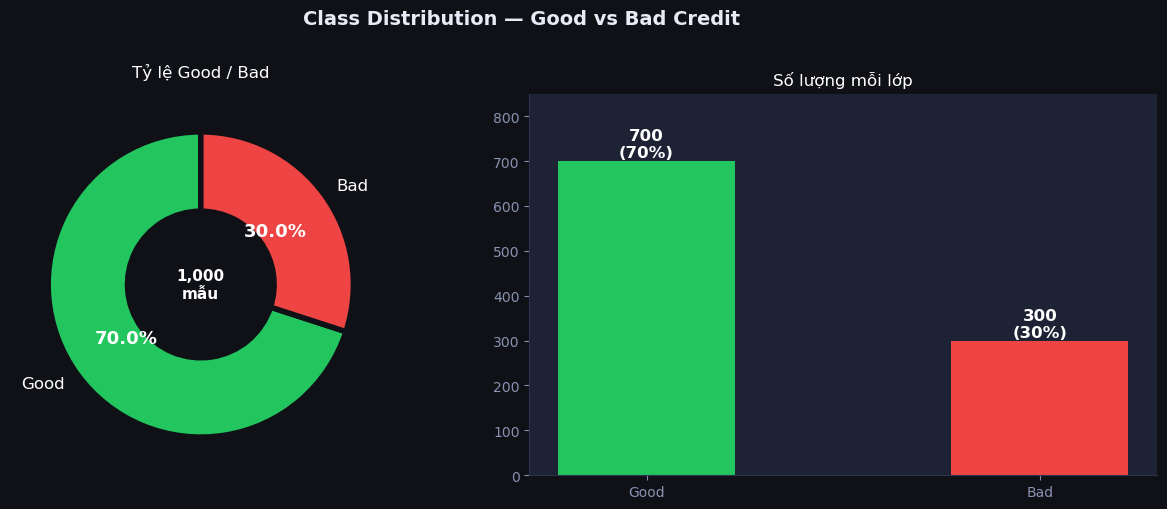

💾 Lưu: class_distribution.png

📌 Nhận xét: Tỷ lệ 70/30 — mất cân bằng nhẹ.
   → Cần dùng class_weight="balanced" hoặc SMOTE khi train model.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Class Distribution — Good vs Bad Credit', color=COLORS['text'],
             fontsize=14, fontweight='bold', y=1.01)

# --- Donut chart ---
ax = axes[0]
ax.set_facecolor(COLORS['card'])
counts = df['label_str'].value_counts()
clrs = [COLORS['good'], COLORS['bad']]
wedge_props = dict(width=0.52, edgecolor=COLORS['bg'], linewidth=4)
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=clrs, wedgeprops=wedge_props,
    textprops={'color': 'white', 'fontsize': 12},
    startangle=90
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
ax.set_title('Tỷ lệ Good / Bad', color='white', fontsize=12, pad=12)
ax.text(0, 0, '1,000\nmẫu', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold')

# --- Bar chart ---
ax2 = axes[1]
ax2.set_facecolor(COLORS['card'])
bars = ax2.bar(counts.index, counts.values, color=clrs,
               edgecolor='none', width=0.45)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{val}\n({val/len(df)*100:.0f}%)',
             ha='center', color='white', fontsize=12, fontweight='bold')
ax2.set_title('Số lượng mỗi lớp', color='white', fontsize=12)
ax2.tick_params(colors=COLORS['muted'])
ax2.spines[['top','right']].set_visible(False)
ax2.set_ylim(0, 850)

for spine in ax2.spines.values():
    spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: class_distribution.png')
print()
print('📌 Nhận xét: Tỷ lệ 70/30 — mất cân bằng nhẹ.')
print('   → Cần dùng class_weight="balanced" hoặc SMOTE khi train model.')

## 📈 Bước 5 — Default Rate theo Mục Đích Vay (Purpose)

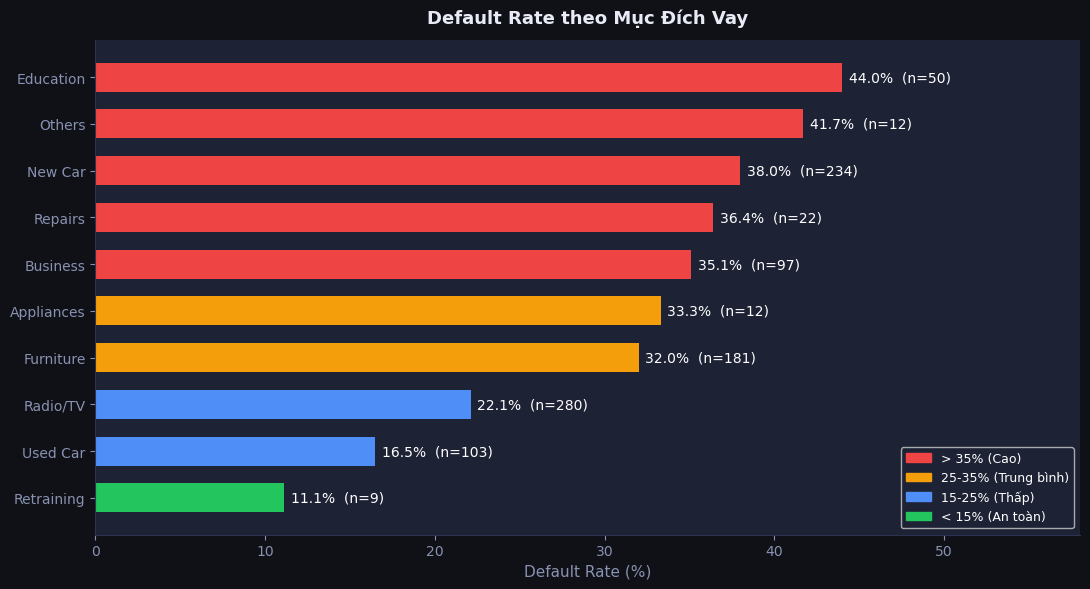

💾 Lưu: default_by_purpose.png

📌 Nhận xét:
   Rủi ro CAO : Giáo dục (44.0%), New Car (38.0%), Kinh doanh (35.1%)
   Rủi ro THẤP: Xe cũ (16.5%), Đào tạo (11.1%)


In [6]:
def default_rate(df, col):
    """Tính tỷ lệ default (Bad) theo từng giá trị của cột col."""
    return df.groupby(col)['label'].apply(
        lambda x: (x == 2).mean() * 100
    ).round(1)

# Default rate theo purpose
dr_purpose = default_rate(df, 'purpose_str').sort_values(ascending=True)
count_purpose = df.groupby('purpose_str').size().reindex(dr_purpose.index)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['card'])

# Màu theo mức rủi ro
bar_colors = [
    COLORS['bad']    if v > 35 else
    COLORS['warn']   if v > 25 else
    COLORS['accent'] if v > 15 else
    COLORS['good']
    for v in dr_purpose.values
]

bars = ax.barh(dr_purpose.index, dr_purpose.values,
               color=bar_colors, edgecolor='none', height=0.62)

for bar, val, cnt in zip(bars, dr_purpose.values, count_purpose.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (n={cnt})',
            va='center', color='white', fontsize=10)

ax.set_xlabel('Default Rate (%)', color=COLORS['muted'], fontsize=11)
ax.set_title('Default Rate theo Mục Đích Vay', color=COLORS['text'],
             fontsize=13, pad=12, fontweight='bold')
ax.tick_params(colors=COLORS['muted'], labelsize=10)
ax.set_xlim(0, 58)
ax.spines[['top','right']].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor(COLORS['border'])

# Legend
patches = [
    mpatches.Patch(color=COLORS['bad'],    label='> 35% (Cao)'),
    mpatches.Patch(color=COLORS['warn'],   label='25-35% (Trung bình)'),
    mpatches.Patch(color=COLORS['accent'], label='15-25% (Thấp)'),
    mpatches.Patch(color=COLORS['good'],   label='< 15% (An toàn)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9,
          facecolor=COLORS['card'], labelcolor='white')

plt.tight_layout()
plt.savefig('default_by_purpose.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: default_by_purpose.png')
print()
print('📌 Nhận xét:')
print('   Rủi ro CAO : Giáo dục (44.0%), New Car (38.0%), Kinh doanh (35.1%)')
print('   Rủi ro THẤP: Xe cũ (16.5%), Đào tạo (11.1%)')

## 📈 Bước 6 — Default Rate theo Duration & Credit Amount

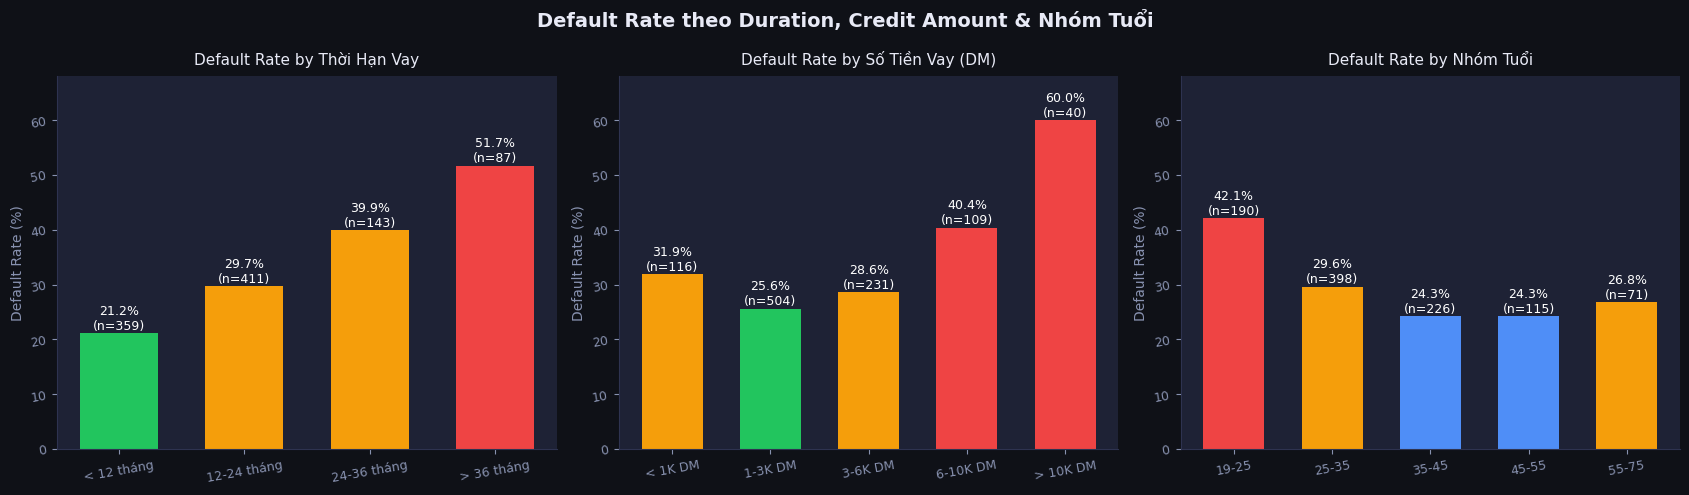

💾 Lưu: default_by_duration_amount_age.png

📌 Nhận xét Duration  : <12 tháng=15% → >36 tháng=47.9% (rủi ro tăng 3x!)
📌 Nhận xét Amount    : >10K DM = 60% default (rủi ro rất cao)
📌 Nhận xét Age       : 19-25 tuổi = 40.9% (người trẻ rủi ro cao nhất)


In [7]:
df_b = df.copy()
df_b['duration_bucket'] = pd.cut(
    df_b['duration'], bins=[0, 12, 24, 36, 72],
    labels=['< 12 tháng', '12-24 tháng', '24-36 tháng', '> 36 tháng']
)
df_b['amount_bucket'] = pd.cut(
    df_b['amount'], bins=[0, 1000, 3000, 6000, 10000, 99999],
    labels=['< 1K DM', '1-3K DM', '3-6K DM', '6-10K DM', '> 10K DM']
)
df_b['age_bucket'] = pd.cut(
    df_b['age'], bins=[18, 25, 35, 45, 55, 75],
    labels=['19-25', '25-35', '35-45', '45-55', '55-75']
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Default Rate theo Duration, Credit Amount & Nhóm Tuổi',
             color=COLORS['text'], fontsize=14, fontweight='bold')

plots = [
    ('duration_bucket', 'Thời Hạn Vay',
     [COLORS['good'], COLORS['warn'], COLORS['warn'], COLORS['bad']]),
    ('amount_bucket', 'Số Tiền Vay (DM)',
     [COLORS['warn'], COLORS['good'], COLORS['warn'], COLORS['bad'], COLORS['bad']]),
    ('age_bucket', 'Nhóm Tuổi',
     [COLORS['bad'], COLORS['warn'], COLORS['accent'], COLORS['accent'], COLORS['warn']]),
]

for ax, (col, title, clrs) in zip(axes, plots):
    ax.set_facecolor(COLORS['card'])
    dr = default_rate(df_b, col)
    cnt = df_b.groupby(col).size()

    bars = ax.bar(dr.index.astype(str), dr.values,
                  color=clrs[:len(dr)], edgecolor='none', width=0.62)
    for bar, val, c in zip(bars, dr.values, cnt.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.6,
                f'{val:.1f}%\n(n={c})',
                ha='center', color='white', fontsize=9)

    ax.set_title(f'Default Rate by {title}', color=COLORS['text'],
                 fontsize=11, pad=8)
    ax.set_ylabel('Default Rate (%)', color=COLORS['muted'])
    ax.tick_params(colors=COLORS['muted'], labelsize=9, rotation=10)
    ax.set_ylim(0, 68)
    ax.spines[['top','right']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('default_by_duration_amount_age.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: default_by_duration_amount_age.png')
print()
print('📌 Nhận xét Duration  : <12 tháng=15% → >36 tháng=47.9% (rủi ro tăng 3x!)')
print('📌 Nhận xét Amount    : >10K DM = 60% default (rủi ro rất cao)')
print('📌 Nhận xét Age       : 19-25 tuổi = 40.9% (người trẻ rủi ro cao nhất)')

## 📈 Bước 7 — Default Rate theo Savings & Checking Account

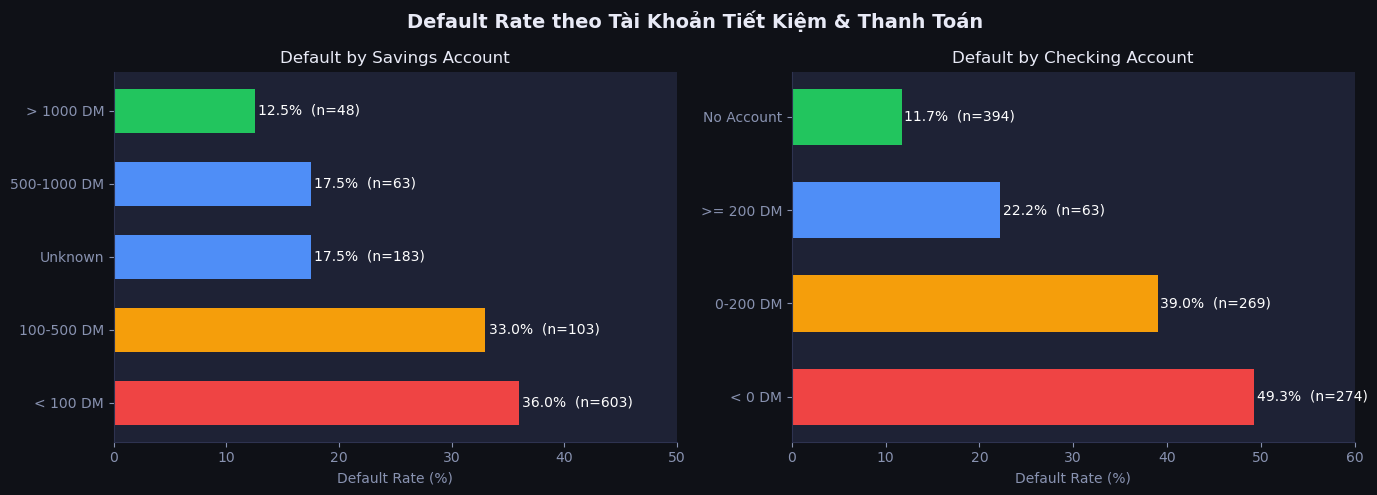

💾 Lưu: default_by_savings_checking.png

📌 Savings  : < 100 DM (36%) vs > 1000 DM (12.5%) — chênh lệch 3x!
📌 Checking : < 0 DM (Am) có default rate cao nhất!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Default Rate theo Tài Khoản Tiết Kiệm & Thanh Toán',
             color=COLORS['text'], fontsize=14, fontweight='bold')

# --- Savings ---
ax1 = axes[0]
ax1.set_facecolor(COLORS['card'])
dr_sav = default_rate(df, 'savings_str')
order_sav = ['< 100 DM', '100-500 DM', 'Unknown', '500-1000 DM', '> 1000 DM']
dr_sav = dr_sav.reindex([o for o in order_sav if o in dr_sav.index])
cnt_sav = df.groupby('savings_str').size().reindex(dr_sav.index)
clrs_sav = [COLORS['bad'], COLORS['warn'], COLORS['accent'],
            COLORS['accent'], COLORS['good']]
bars = ax1.barh(dr_sav.index, dr_sav.values,
                color=clrs_sav, edgecolor='none', height=0.6)
for bar, val, cnt in zip(bars, dr_sav.values, cnt_sav.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%  (n={cnt})',
             va='center', color='white', fontsize=10)
ax1.set_xlabel('Default Rate (%)', color=COLORS['muted'])
ax1.set_title('Default by Savings Account', color=COLORS['text'], fontsize=12)
ax1.tick_params(colors=COLORS['muted'], labelsize=10)
ax1.set_xlim(0, 50)
ax1.spines[['top','right']].set_visible(False)

# --- Checking ---
ax2 = axes[1]
ax2.set_facecolor(COLORS['card'])
dr_chk = default_rate(df, 'checking_str')
order_chk = ['< 0 DM', '0-200 DM', '>= 200 DM', 'No Account']
dr_chk = dr_chk.reindex([o for o in order_chk if o in dr_chk.index])
cnt_chk = df.groupby('checking_str').size().reindex(dr_chk.index)
clrs_chk = [COLORS['bad'], COLORS['warn'], COLORS['accent'], COLORS['good']]
bars2 = ax2.barh(dr_chk.index, dr_chk.values,
                 color=clrs_chk, edgecolor='none', height=0.6)
for bar, val, cnt in zip(bars2, dr_chk.values, cnt_chk.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%  (n={cnt})',
             va='center', color='white', fontsize=10)
ax2.set_xlabel('Default Rate (%)', color=COLORS['muted'])
ax2.set_title('Default by Checking Account', color=COLORS['text'], fontsize=12)
ax2.tick_params(colors=COLORS['muted'], labelsize=10)
ax2.set_xlim(0, 60)
ax2.spines[['top','right']].set_visible(False)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('default_by_savings_checking.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: default_by_savings_checking.png')
print()
print('📌 Savings  : < 100 DM (36%) vs > 1000 DM (12.5%) — chênh lệch 3x!')
print('📌 Checking : < 0 DM (Am) có default rate cao nhất!')

## 📊 Bước 8 — Phân phối Numeric Features (Good vs Bad)

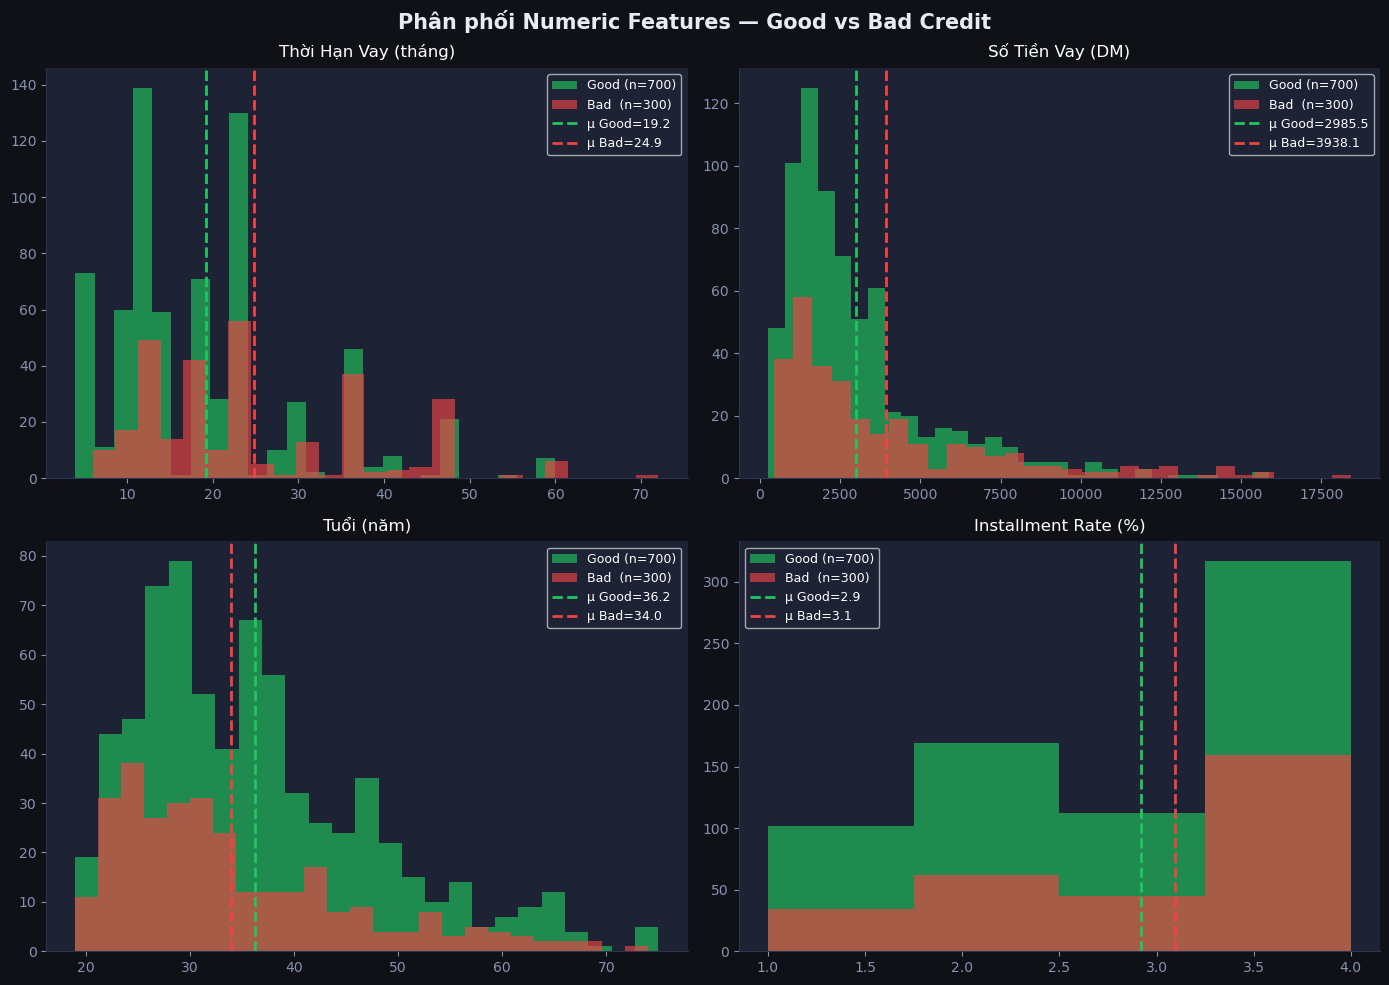

💾 Lưu: numeric_distributions.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Phân phối Numeric Features — Good vs Bad Credit',
             color=COLORS['text'], fontsize=15, fontweight='bold')

pairs = [
    ('duration',         'Thời Hạn Vay (tháng)', 25),
    ('amount',           'Số Tiền Vay (DM)',      30),
    ('age',              'Tuổi (năm)',            25),
    ('installment_rate', 'Installment Rate (%)',  4),
]

for ax, (col, title, bins) in zip(axes.flatten(), pairs):
    ax.set_facecolor(COLORS['card'])
    good_d = df[df['label'] == 1][col]
    bad_d  = df[df['label'] == 2][col]

    ax.hist(good_d, bins=bins, alpha=0.65, color=COLORS['good'],
            label=f'Good (n={len(good_d)})', edgecolor='none')
    ax.hist(bad_d,  bins=bins, alpha=0.65, color=COLORS['bad'],
            label=f'Bad  (n={len(bad_d)})',  edgecolor='none')

    ax.axvline(good_d.mean(), color=COLORS['good'], linestyle='--',
               linewidth=2, label=f'μ Good={good_d.mean():.1f}')
    ax.axvline(bad_d.mean(),  color=COLORS['bad'],  linestyle='--',
               linewidth=2, label=f'μ Bad={bad_d.mean():.1f}')

    ax.set_title(title, color='white', fontsize=12, pad=8)
    ax.tick_params(colors=COLORS['muted'])
    ax.legend(fontsize=9, facecolor=COLORS['card'], labelcolor='white')
    ax.spines[['top','right']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: numeric_distributions.png')

## 🔥 Bước 9 — Correlation Heatmap

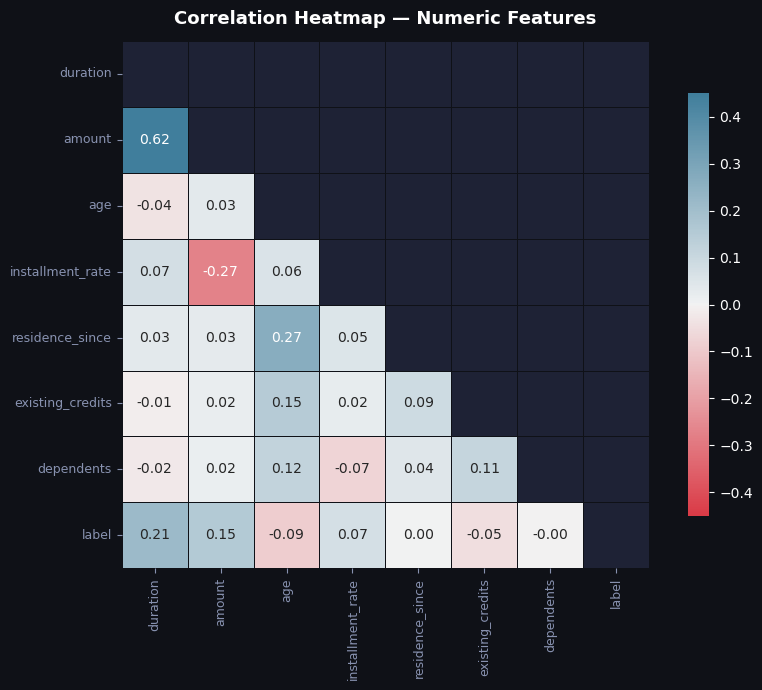

💾 Lưu: correlation_heatmap.png

📌 label tương quan dương với duration (+) và amount (+)
   → Vay lâu hơn và nhiều hơn → rủi ro cao hơn.


In [10]:
num_cols = ['duration', 'amount', 'age', 'installment_rate',
            'residence_since', 'existing_credits', 'dependents', 'label']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['card'])

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(10, 230, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=0.45, vmin=-0.45,
    annot=True, fmt='.2f', square=True, ax=ax,
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 10},
    linewidths=0.5, linecolor=COLORS['bg']
)
ax.set_title('Correlation Heatmap — Numeric Features',
             color='white', fontsize=13, pad=12, fontweight='bold')
ax.tick_params(colors=COLORS['muted'], labelsize=9)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: correlation_heatmap.png')
print()
print('📌 label tương quan dương với duration (+) và amount (+)')
print('   → Vay lâu hơn và nhiều hơn → rủi ro cao hơn.')

## 📈 Bước 10 — Default Rate theo Employment & Credit History

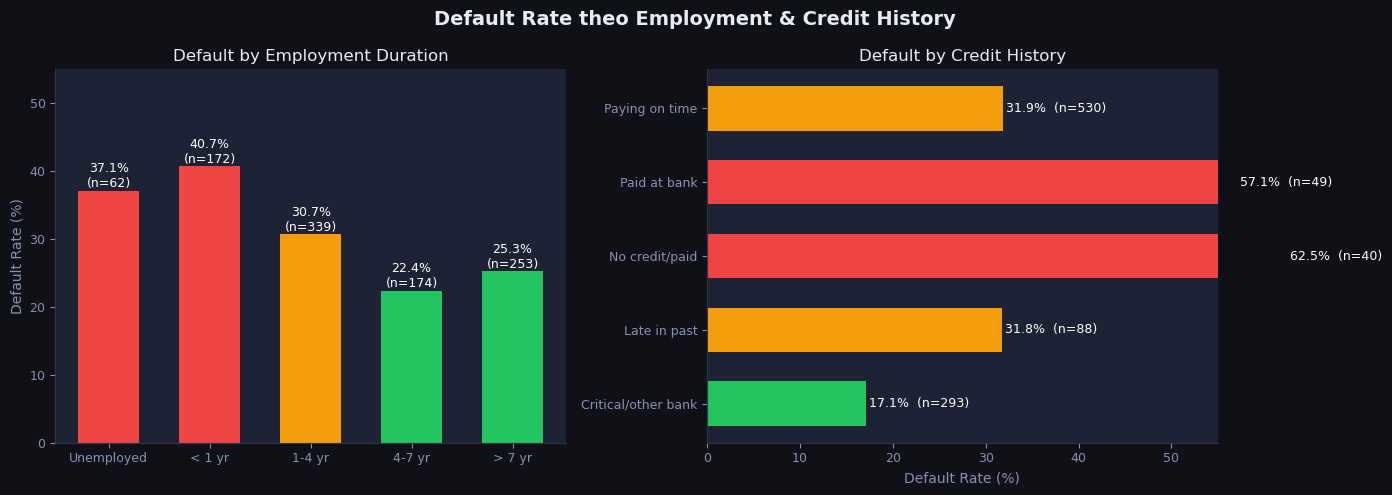

💾 Lưu: default_by_employment_history.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Default Rate theo Employment & Credit History',
             color=COLORS['text'], fontsize=14, fontweight='bold')

# Employment
ax1 = axes[0]
ax1.set_facecolor(COLORS['card'])
dr_emp = default_rate(df, 'employment_str')
order_emp = ['Unemployed', '< 1 yr', '1-4 yr', '4-7 yr', '> 7 yr']
dr_emp = dr_emp.reindex([o for o in order_emp if o in dr_emp.index])
cnt_emp = df.groupby('employment_str').size().reindex(dr_emp.index)
clrs_emp = [COLORS['bad'], COLORS['bad'], COLORS['warn'],
            COLORS['good'], COLORS['good']]
bars1 = ax1.bar(dr_emp.index.astype(str), dr_emp.values,
                color=clrs_emp, edgecolor='none', width=0.6)
for bar, val, cnt in zip(bars1, dr_emp.values, cnt_emp.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={cnt})', ha='center', color='white', fontsize=9)
ax1.set_title('Default by Employment Duration', color=COLORS['text'], fontsize=12)
ax1.set_ylabel('Default Rate (%)', color=COLORS['muted'])
ax1.tick_params(colors=COLORS['muted'], labelsize=9)
ax1.set_ylim(0, 55)
ax1.spines[['top','right']].set_visible(False)

# Credit History
ax2 = axes[1]
ax2.set_facecolor(COLORS['card'])
dr_hist = default_rate(df, 'history_str')
cnt_hist = df.groupby('history_str').size().reindex(dr_hist.index)
clrs_hist = [
    COLORS['good'] if v < 20 else
    COLORS['warn'] if v < 35 else
    COLORS['bad']
    for v in dr_hist.values
]
bars2 = ax2.barh(dr_hist.index.astype(str), dr_hist.values,
                 color=clrs_hist, edgecolor='none', height=0.6)
for bar, val, cnt in zip(bars2, dr_hist.values, cnt_hist.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%  (n={cnt})', va='center', color='white', fontsize=9)
ax2.set_xlabel('Default Rate (%)', color=COLORS['muted'])
ax2.set_title('Default by Credit History', color=COLORS['text'], fontsize=12)
ax2.tick_params(colors=COLORS['muted'], labelsize=9)
ax2.set_xlim(0, 55)
ax2.spines[['top','right']].set_visible(False)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.savefig('default_by_employment_history.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('💾 Lưu: default_by_employment_history.png')

## 💡 Bước 11 — Key Insights & Tóm Tắt EDA

In [12]:
print('=' * 65)
print('  KEY INSIGHTS TỪ EDA — GERMAN CREDIT DATASET')
print('=' * 65)

insights = [
    ('Class Imbalance',      '70% Good / 30% Bad → dùng class_weight hoặc SMOTE'),
    ('Duration & Risk',      '< 12 tháng: 15%  →  > 36 tháng: 47.9%  (+3x rủi ro!)'),
    ('Amount & Risk',        '< 1K DM: 31.9%   →  > 10K DM: 60.0%  (rủi ro rất cao)'),
    ('Age & Risk',           '19-25 tuổi: 40.9% (trẻ rủi ro cao nhất)'),
    ('Savings & Risk',       '< 100 DM: 36%  vs  > 1000 DM: 12.5%  (chênh 3x!)'),
    ('Checking Account',     'Số dư âm (< 0 DM) → default rate cao nhất ~50%+'),
    ('Purpose: Rủi ro cao',  'Giáo dục (44.0%), New Car (38.0%), Kinh doanh (35.1%)'),
    ('Purpose: An toàn',     'Xe cũ (16.5%), Đào tạo lại (11.1%)'),
    ('Employment',           'Thất nghiệp (37.1%) và < 1 năm (40.7%) rủi ro cao'),
    ('Credit History',       'Từng trễ hạn → rủi ro cao hơn nhiều so với đúng hạn'),
]

for i, (title, detail) in enumerate(insights, 1):
    icon = '🔴' if any(k in title for k in ['cao','Imb']) else '🟡' if 'Risk' in title else '🟢'
    print(f'  {i:2d}. {icon} {title:<25}: {detail}')

print('=' * 65)
print('\n📊 Thống kê tóm tắt:')
num_features = ['duration', 'amount', 'age']
for col in num_features:
    g = df[df['label']==1][col].mean()
    b = df[df['label']==2][col].mean()
    print(f'   {col:<20}: Good μ={g:.1f}  |  Bad μ={b:.1f}  |  Δ={b-g:+.1f}')

  KEY INSIGHTS TỪ EDA — GERMAN CREDIT DATASET
   1. 🔴 Class Imbalance          : 70% Good / 30% Bad → dùng class_weight hoặc SMOTE
   2. 🟡 Duration & Risk          : < 12 tháng: 15%  →  > 36 tháng: 47.9%  (+3x rủi ro!)
   3. 🟡 Amount & Risk            : < 1K DM: 31.9%   →  > 10K DM: 60.0%  (rủi ro rất cao)
   4. 🟡 Age & Risk               : 19-25 tuổi: 40.9% (trẻ rủi ro cao nhất)
   5. 🟡 Savings & Risk           : < 100 DM: 36%  vs  > 1000 DM: 12.5%  (chênh 3x!)
   6. 🟢 Checking Account         : Số dư âm (< 0 DM) → default rate cao nhất ~50%+
   7. 🔴 Purpose: Rủi ro cao      : Giáo dục (44.0%), New Car (38.0%), Kinh doanh (35.1%)
   8. 🟢 Purpose: An toàn         : Xe cũ (16.5%), Đào tạo lại (11.1%)
   9. 🟢 Employment               : Thất nghiệp (37.1%) và < 1 năm (40.7%) rủi ro cao
  10. 🟢 Credit History           : Từng trễ hạn → rủi ro cao hơn nhiều so với đúng hạn

📊 Thống kê tóm tắt:
   duration            : Good μ=19.2  |  Bad μ=24.9  |  Δ=+5.7
   amount              : Good μ=298